In [1]:
# ensure we run on the CPU
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

# Import netket library
import netket as nk

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
from lattice import Lattice
import pyrochlore
import visual


[Alarics-MacBook-Air.local:56283] shmem: mmap: an error occurred while determining whether or not /var/folders/zw/92jnrf1n0710vn256dpg6bsw0000gn/T//ompi.Alarics-MacBook-Air.501/jf.0/2429419520/sm_segment.Alarics-MacBook-Air.501.90ce0000.0 could be created.


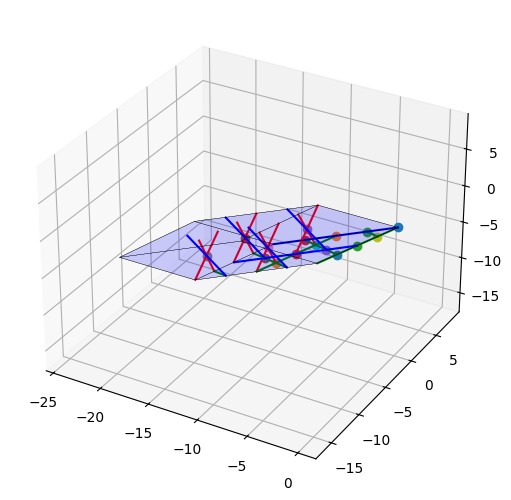

In [21]:

# Build the lattice
# full_lat = Lattice(pyrochlore.primitive, [[2,0,0],[0,2,0],[0,0,2]])
full_lat = Lattice(pyrochlore.primitive, [[1,-1,-1],[-1,1,-1],[-1,-1,1] ])

fig =plt.figure()
ax=fig.add_axes([0,0,1,1],projection='3d')
visual.plot_cell(ax, full_lat)

In [22]:
#Couplings Jzz and Jpm
Jzz = 1
Jpm = 0.03

B = [0.1,0,0]

In [23]:
# Define custom graph
# only a single coupling type
edge_colors = [[x['from_idx'], x['to_idx'], 1] for x in full_lat.bonds] 


# Define the netket graph object
g = nk.graph.Graph(edges=edge_colors)

In [24]:
#Sigma^z*Sigma^z interactions
sigmaz = [[1, 0], [0, -1]]
mszsz = (np.kron(sigmaz, sigmaz)) - np.identity(4)

#Exchange interactions
exchange = np.asarray([[0, 0, 0, 0], [0, 0, 2, 0], [0, 2, 0, 0], [0, 0, 0, 0]])

bond_operator = [
    (Jzz * mszsz).tolist(),
    (Jpm * exchange).tolist()
]

bond_color = [1, 1]

In [25]:
from netket.operator import spin
B_strength = {
    '0' : B @ np.array([1,1,1])/np.sqrt(3),
    '1' : B @ np.array([1,-1,-1])/np.sqrt(3),
    '2' : B @ np.array([-1,1,-1])/np.sqrt(3),
    '3' : B @ np.array([-1,-1,1])/np.sqrt(3),
}



In [26]:
# Spin based Hilbert Space
hi = nk.hilbert.Spin(s=0.5, 
                     #total_sz=0.0, 
                     N=g.n_nodes, inverted_ordering=False)
# Custom Hamiltonian operator
H_xxz = nk.operator.GraphOperator(hi, graph=g, bond_ops=bond_operator, bond_ops_colors=bond_color) 
H_Zeeman = sum([B_strength[a.sl_name] * spin.sigmax(hi, i) for i, a in enumerate(full_lat.atoms)])

In [27]:
import netket.nn as nknn
import flax.linen as nn

import jax.numpy as jnp

# model = nk.models.tensor_networks.MPSPeriodic(hi, 10)

In [28]:
from netket.sampler import MetropolisSampler

In [29]:
# structure factor - the observable to measure
def make_rf(rf):
    return spin.sigmap(hi, rf[0])*spin.sigmam(hi, rf[1])*spin.sigmap(hi, rf[2])*spin.sigmam(hi, rf[3])*spin.sigmap(hi, rf[4])*spin.sigmam(hi, rf[5])

def make_conj_rf(rf):
    return spin.sigmam(hi, rf[0])*spin.sigmap(hi, rf[1])*spin.sigmam(hi, rf[2])*spin.sigmap(hi, rf[3])*spin.sigmam(hi, rf[4])*spin.sigmap(hi, rf[5])


ringflips = []
conj_ringflips = []
for mu in range(4):
    rfo = nk.operator.LocalOperator(hi, dtype=complex)
    conj_rfo = nk.operator.LocalOperator(hi, dtype=complex)
    for ring in pyrochlore.get_ringflips(full_lat, mu):
        rfo += make_rf(ring)
        conj_rfo += make_conj_rf(ring)
    ringflips.append(rfo)
    conj_ringflips.append(conj_rfo)



In [30]:
# # helps the VMC along 
# # flips flippable plaquettes, otherwise no-op
# ringx_mat = np.identity(64)
# ringx_mat[0b101010,0b101010] = 0
# ringx_mat[0b010101,0b010101] = 0
# ringx_mat[0b101010,0b010101] = 1
# ringx_mat[0b010101,0b101010] = 1

# # # rotates elementary tetrahedra
# # sigmaz_rot = np.identity(2**4)
# # sigmax_rot[0b1010, 0b1010] = 

# import scipy as sp


# ring_ex = [nk.operator.LocalOperator(hi, operators=sp.sparse.csr_matrix(ringx_mat), acting_on=rf) 
#     for rf in pyrochlore.get_ringflips(full_lat)]




# # gauge_ham = sum([spin.sigmaz(hi, i) for i in range(len(full_lat.atoms))])
# # these must be permutation matrices
# rule_list_ops = sum(ring_ex)
# rule_ops_weights = [1]*32

# assert rule_list_ops.n_operators == len(rule_ops_weights)

# s = sum(rule_ops_weights)
# rule_ops_weights = np.array([x/s for x in rule_ops_weights])

AssertionError: 

In [32]:
symmetries = g.automorphisms()

#Feature dimensions of hidden layers, from first to last
feature_dims = (8,8,8,8)

#Number of layers
num_layers = 4

#Define the GCNN 
# model = nk.models.GCNN(symmetries = symmetries, layers = num_layers, features = feature_dims)
model = nk.models.tensor_networks.MPSPeriodic(hilbert=hi, bond_dim=2)

spin_ham = H_xxz+H_Zeeman

# RingflipRule = nk.sampler.rules.CustomRuleNumpy(rule_list_ops, rule_ops_weights)

# We shall use an exchange Sampler which preserves the global magnetization (as this is a conserved quantity in the model)
# sa = nk.sampler.MetropolisExchange(hilbert=hi, graph=g, d_max = 2)
sa = nk.sampler.ParallelTemperingHamiltonian(hi, spin_ham)
# sa = nk.sampler.MetropolisHamiltonian(hilbert=hi, hamiltonian=sum(ringflips)+sum(conj_ringflips) )
# sa= nk.sampler.MetropolisSamplerNumpy(hilbert=hi, rule=RingflipRule)
# nk.sampler.MetropolisS


symmetries = g.automorphisms()

# Construct the variational state
vs = nk.vqs.MCState(sa, model, n_samples=1008)

opt = nk.optimizer.Adam()
# opt = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.01, holomorphic=False)

# We can then specify a Variational Monte Carlo object, using the Hamiltonian, sampler and optimizers chosen.
# Note that we also specify the method to learn the parameters of the wave-function: here we choose the efficient
# Stochastic reconfiguration (Sr), here in an iterative setup
gs = nk.VMC(
    hamiltonian=spin_ham, 
    optimizer=opt, 
    variational_state=vs, 
    preconditioner=sr)


In [33]:
# Run the optimization protocol
gs.run(out='pyro16_Adam_MPS', n_iter=600, obs={f'ringflip {mu}': ringflips[mu] for mu in [0,1,2,3]})

  0%|                                                                                                         …

(JsonLog('pyro16_Adam_MPS', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.6716723442077637
   	Params: 0.20620965957641602,)

In [ ]:
# Load the data from the .log file
import json 

data=json.load(open("pyro16_Adam_MPS.log"))

iters = data['Energy']['iters']
energy=np.array(data['Energy']['Mean']['real'])+6 * (full_lat.num_atoms // 2)
rf_data=[data[f'ringflip {j}']['Mean']['real'] for j in range(4)]


In [ ]:
fig, (ax1,ax2) = plt.subplots(nrows=2,sharex=True)
ax1.plot(iters, energy, color='blue', label='Energy')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
# ax2 = ax1.twinx() 
for mu in range(4):
    ax2.plot(iters, np.array(rf_data[mu]), label=f'sl {mu}')
ax2.set_ylabel('Ringflip exp val')
ax2.set_ylim([0,0.01])
ax1.legend(loc=2)
ax2.legend(loc=1)
plt.show()

In [66]:
def pprint(name, arraydata):
    print(f"{name} = {np.mean(arraydata)} ± {np.std(arraydata)}")

# pprint("Structure Factor", sf[400:])
pprint("Energy", energy[400:])

Energy = -31.99441481762702 ± 0.02782126158821521


In [34]:
full_lat.num_atoms

16